Використай цей шаблон в роботі з датасетом.      
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.      
Обмежся функціями з наведених бібліотек.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

1. Завантаж датасет з бібліотеки seaborn:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')

2. Переглянь перші рядки датасету. Зроби висновок, чи коректно він завантажився.

In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


3. Перевір типи стовпців. Які з них потребують перетворення?

In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


4. Перевір статистику по УСІМ стовпцям датасету.

In [ ]:
titanic.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


5. Необхідно створити єдиний стовпчик, що вказує кількість родичів для кожного пасажира на борту, замість:
- кількість братів/сестер або чоловіків/дружин на борту;
- кількість батьків або дітей на борту;

Булева ознака: стовпчик 'alone'=True, якщо пасажир подорожував один (без родичів на борту).        
Перевір, щоб для одиноких пасажирів новий стовпчик мав значення 0.      
Після створення нового стовпчика, дропни "sibsp", "parch", "alone".     
Результат представ у вигляді підрахунку кількості пропущених значень (NaN) у стовпці relatives.

In [ ]:
titanic['relatives'] = titanic['sibsp'] + titanic['parch']

check_alone = titanic[titanic['alone'] == True][['relatives', 'alone']].head()
print("Перевірка для одиноких пасажирів (мають бути нулі):")
print(check_alone)

titanic.drop(columns=['sibsp', 'parch', 'alone'], inplace=True)

nan_count = titanic['relatives'].isnull().sum()
print("\nКількість пропущених значень у стовпці 'relatives':")
print(nan_count)

Перевірка для одиноких пасажирів (мають бути нулі):
    relatives  alone
2           0   True
4           0   True
5           0   True
6           0   True
11          0   True

Кількість пропущених значень у стовпці 'relatives':
0


6. Перевір, як часто зустрічається певна кількість родичів в новому стовпці.    
Результат представ у вигляді таблиці, побудованої з використанням групування та агрегації:

In [ ]:
relatives_stats = titanic.groupby('relatives').agg(passenger_count=('relatives', 'count'))

relatives_stats

,passenger_count
relatives,
0,537
1,161
2,102
3,29
4,15
5,22
6,12
7,6
10,7


7. Використовуючи цикл заміни кількість родичів, що перевищує число 5(п'ять) на значення "above 5"(понад п'ять).       
Запиши значення в новий стовпчик ʼrelatives_categoryʼ.     
Результат представ у вигляді таблиці, побудованої з використанням групування та агрегації:

In [ ]:
categories = []

for value in titanic['relatives']:
    if value > 5:
        categories.append('above 5')
    else:
        categories.append(str(value))

titanic['relatives_category'] = categories

rel_cat_stats = titanic.groupby('relatives_category').agg(passenger_count=('relatives_category', 'count'))

print("Статистика за категоріями родичів:")
rel_cat_stats

Статистика за категоріями родичів:


,passenger_count
relatives_category,
0,537
1,161
2,102
3,29
4,15
5,22
above 5,25


8. Необхідно вивести на екран статистику по відсотковому показнику пасажирів з кількістю родичів більше 5 відносно загального числа пасажирів для кожного з міст посадки. Для цього:
- порахуй загальну кількість пасажирів в кожному з міст посадки,
- знайди число пасажирів з кількістю родичів більше 5 в кожному з міст посадки,
- поділи ці два стовчики між собою, перетворивши результат у відсотки (ціле число).        
Відобрази статистику для усіх міст посадки.

In [ ]:
total_by_city = titanic.groupby('embark_town')['relatives'].count()

above_5_by_city = titanic[titanic['relatives'] > 5].groupby('embark_town')['relatives'].count()

percent_stats = (above_5_by_city / total_by_city * 100).fillna(0).astype(int)

print("Відсоток пасажирів з > 5 родичами по містах посадки:")
print(percent_stats)

Відсоток пасажирів з > 5 родичами по містах посадки:
embark_town
Cherbourg      0
Queenstown     0
Southampton    3
Name: relatives, dtype: int64


9. Заповни відсутні значення віку медіаною.

In [ ]:
age_median = titanic['age'].median()

titanic['age'] = titanic['age'].fillna(age_median)

print(f"Медіана віку, якою заповнили пропуски: {age_median}")
print("Кількість пропусків у стовпці 'age' після заповнення:")
print(titanic['age'].isnull().sum())

Медіана віку, якою заповнили пропуски: 28.0
Кількість пропусків у стовпці 'age' після заповнення:
0


10. Створи новий стовпець, де вік представлено категорією, замість числа (наприклад: до 14 років, 14-34 роки, 35-59 років, 60 і більше років). Виконай задачу з використанням користувацької функції. Осіб з невідомим віком познач відповідно.

In [ ]:
def categorize_age(age):
    if pd.isnull(age):
        return 'Unknown'
    elif age < 14:
        return 'до 14 років'
    elif 14 <= age <= 34:
        return '14-34 роки'
    elif 35 <= age <= 59:
        return '35-59 років'
    else:
        return '60 і більше років'

titanic['age_category'] = titanic['age'].apply(categorize_age)

age_stats = titanic.groupby('age_category').agg(count=('age_category', 'count'))

print("Розподіл пасажирів за віковими категоріями:")
print(age_stats)

Розподіл пасажирів за віковими категоріями:
                   count
age_category            
14-34 роки           584
35-59 років          209
60 і більше років     27
до 14 років           71


11. Перевір, в якій віковій категорії була найвища смертність.     
Для цього рекомендується перетворити стовпець 'alive' в булевий тип.    
 Потім підрахувати загальну кількість пасажирів та кількість тих, хто не вижив.      
 Потім обчисли відносний показниках для кожної категорії.

In [ ]:
titanic['is_dead'] = titanic['alive'] == 'no'

death_stats = titanic.groupby('age_category')['is_dead'].agg(['count', 'sum'])

death_stats.columns = ['total_passengers', 'total_deaths']

death_stats['mortality_rate_%'] = (death_stats['total_deaths'] / death_stats['total_passengers'] * 100).round(1)

print("Статистика смертності за віковими категоріями:")
death_stats.sort_values(by='mortality_rate_%', ascending=False)

Статистика смертності за віковими категоріями:


,total_passengers,total_deaths,mortality_rate_%
age_category,,,
60 і більше років,27,20,74.1
14-34 роки,584,378,64.7
35-59 років,209,122,58.4
до 14 років,71,29,40.8


**Бонусне завдання:**

Підготуй розгорнуту статистику смертності по категорії віку, класу квитка, рівню каюти та кількості родичів.      
Які фактори, на твою думку, найбільше пов'язані з рівнем смерності? (наприклад: найбільша смертність у відсотковому значенні спостерігається серед вікової групи ... класу квитка.... при наявності ... родичів та для рівня каюти.... Фактор ... має найвищий вплив на смертність)

In [ ]:
bonus_stats = titanic.groupby(['pclass', 'age_category', 'relatives_category']).agg(
    total=('alive', 'count'),
    deaths=('is_dead', 'sum'))

bonus_stats['mortality_rate_%'] = (bonus_stats['deaths'] / bonus_stats['total'] * 100).round(1)

print("Топ-5 груп з найвищою смертністю:")
print(bonus_stats[bonus_stats['total'] > 5].sort_values(by='mortality_rate_%', ascending=False).head(5))

Топ-5 груп з найвищою смертністю:
                                        total  deaths  mortality_rate_%
pclass age_category relatives_category                                 
3      14-34 роки   4                       7       7             100.0
       до 14 років  5                      11      11             100.0
       35-59 років  0                      41      38              92.7
       14-34 роки   above 5                10       9              90.0
       35-59 років  1                       7       6              85.7


In [ ]:
print("Інформація про датасет:")
titanic.info()

print("\nФінальний вигляд таблиці (перші 5 записів):")
titanic.head()

Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   survived            891 non-null    int64   
 1   pclass              891 non-null    int64   
 2   sex                 891 non-null    object  
 3   age                 891 non-null    float64 
 4   fare                891 non-null    float64 
 5   embarked            889 non-null    object  
 6   class               891 non-null    category
 7   who                 891 non-null    object  
 8   adult_male          891 non-null    bool    
 9   deck                203 non-null    category
 10  embark_town         889 non-null    object  
 11  alive               891 non-null    object  
 12  relatives           891 non-null    int64   
 13  relatives_category  891 non-null    object  
 14  age_category        891 non-null    object  
 15  is_dead         

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,deck,embark_town,alive,relatives,relatives_category,age_category,is_dead
0,0,3,male,22.0,7.2500,S,Third,man,True,NaN,Southampton,no,1,1,14-34 роки,True
1,1,1,female,38.0,71.2833,C,First,woman,False,C,Cherbourg,yes,1,1,35-59 років,False
2,1,3,female,26.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,0,0,14-34 роки,False
3,1,1,female,35.0,53.1000,S,First,woman,False,C,Southampton,yes,1,1,35-59 років,False
4,0,3,male,35.0,8.0500,S,Third,man,True,NaN,Southampton,no,0,0,35-59 років,True


### **1. Survival Rate Analysis by Passenger Class**

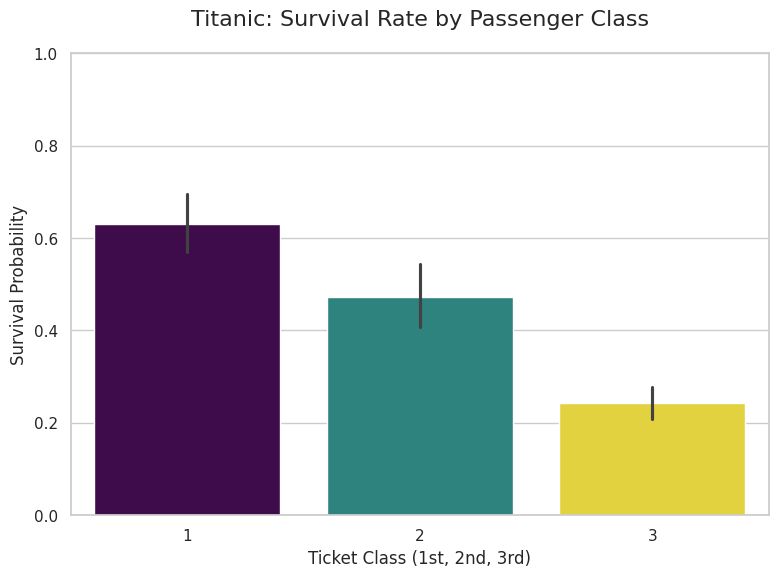

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Графік виживання за класами
plt.figure(figsize=(9, 6))
sns.barplot(x='pclass', y='survived', hue='pclass', data=titanic, palette='viridis', legend=False)
plt.title('Titanic: Survival Rate by Passenger Class', fontsize=16, pad=20)
plt.ylabel('Survival Probability', fontsize=12)
plt.xlabel('Ticket Class (1st, 2nd, 3rd)', fontsize=12)
plt.ylim(0, 1)
plt.show()

**Passengers from the 1st class had a significantly higher survival rate (over 60%) compared to the 3rd class (around 25%), highlighting the impact of socio-economic status on rescue priority.**

### **2. Mortality Rate Analysis by Age Category**

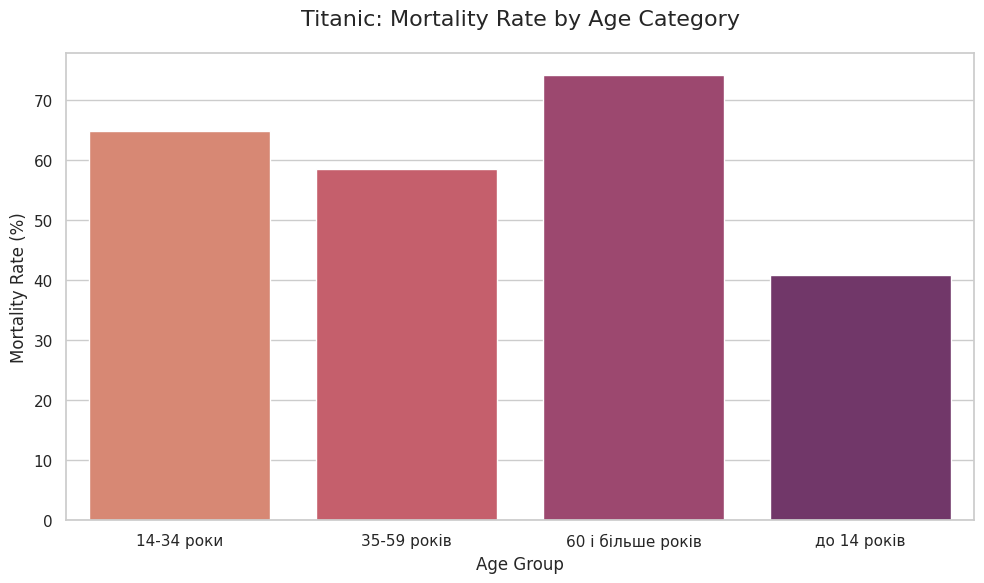

In [ ]:
# Графік смертності за віком
plt.figure(figsize=(10, 6))
df_plot = death_stats.reset_index()
sns.barplot(x='age_category', y='mortality_rate_%', hue='age_category', data=df_plot, palette='flare', legend=False)
plt.title('Titanic: Mortality Rate by Age Category', fontsize=16, pad=20)
plt.ylabel('Mortality Rate (%)', fontsize=12)
plt.xlabel('Age Group', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Key Insight: The highest mortality rate (over 70%) was recorded among seniors (60+). Conversely, children had the lowest mortality rate, which aligns with historical "women and children first" evacuation protocols.**